# Geant4 Detector Simulation & Machine Learning Analysis

Thomas Griffiths, Data Analysis and Machine Learning, Unviersity of Edinburgh, March 2026

In this project, I simulate a simple detector in Geant4 that can distinguish between different particle types and reconstruct their energy. This was achieved by assembling a multi-component detector and applying a machine learning model to reconstruct particle energies and identify particle species - tasks that are central to real collider experiments such as ATLAS and CMS.

## Baseline Detector Geometry:
* Two cylindrical silicon tracking layers at R = 4 and R = 8 inside a 0.5 T solenoid, measuring charged-particle momenta from track sagitta.
* Electromagnetic Calorimeter made of alternating layers liquid argon and lead to record electromagnetic shower energy.
* Hadronic Calorimeter made of alternating layers of iron and scintillating material to record hadronic shower energy.
* Muon detecting layer with endcaps made of aluminum.
* A mixed beam of electrons/muons/photons/protons/pions with diverse number of each species and energies.

![Detector](Images/Detector.png)

This Notebook Covers:
- 1. **Data Reading**
- 2. **Event Reconstruction**
    - 2.1 Momentum and Track Pairing
    - 2.2 Charge from Curvature
    - 2.3 Calorimeter Energy
- 3. **Particle Type Classification**
    - 3.1 Event Level Classification
    - 3.2 Attaching Charge to Classified Events
    - 3.3 Particle Type Energy Calibration
    - 3.4 Energy Deposition
- 4. **Gradient Boosting Classifier - Machine Learning Model**
    - 4.1 Model Architecture
    - 4.2 Feature Importance
    - 4.3 Energy Reconstruction Comparison
    - 4.4 Charge Comparison
    - 4.5 Machine Learning Analysis

# 0. Package Importing

In [389]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
import math
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Data Reading

The first step to analyze the data is to read in and parse the Geant4 simulation outputs. The data is compiled into 6 dataframes, one for the EM calorimeter, one for the hadronic calorimeter, the muon detector, both tracker layers, and finally a truth record containing the correct values which is used for comparison only.

In [390]:
# Read the data from the CSV files into pandas DataFrames
 
em_pd = pd.read_csv('build/output_nt_EMCal.csv', comment = '#', names= ['EventID', 'LayerID', 'Energy']) # EM cal
h_pd = pd.read_csv('build/output_nt_HCal.csv', comment='#', names=['EventID', 'LayerID', 'Energy']) # Hadronic Cal
muon_pd = pd.read_csv('build/output_nt_MuonDetector.csv', comment = '#', names = ['EventID', 'Phi', 'Theta']) # Muon Detector
track1_pd = pd.read_csv('build/output_nt_Tracker1.csv', comment = '#', names= ['EventID', 'TrackID', 'Phi', 'Theta', 'EnergyDeposit', 'PathLength']) # Tracker 1
track2_pd = pd.read_csv('build/output_nt_Tracker2.csv', comment = '#', names= ['EventID', 'TrackID', 'Phi', 'Theta', 'EnergyDeposit', 'PathLength']) # Tracker 2
truth_pd = pd.read_csv('build/output_nt_Truth.csv', comment = '#', names= ['EventID', 'Phi', 'Theta', 'Momentum', 'Particle Code', 'Charge']) # Truth


# Create a mapping of particle codes to their corresponding particle types
code_map = {0: 'electron', 1: 'muon', 2: 'photon', 3: 'hadron', 4: 'hadron', 5: 'hadron', 99: 'other'}

# Create a new column in the truth DataFrame to store the particle types
truth_pd['TrueType'] = truth_pd['Particle Code'].map(code_map)

# Sort the DataFrames by EventID for easier processing
all_event_ids = sorted(truth_pd['EventID'].unique()) 
events_with_tracker_hits = set(track1_pd['EventID'].unique())
events_with_tracker2_hits = set(track2_pd['EventID'].unique())

# Create a new column in the truth DataFrame to store the particle types
def get_species(code, charge):
    if code ==0: return 'positron' if charge > 0 else 'electron'
    if code == 1: return 'muon' if charge < 0 else 'antimuon'
    if code ==2: return 'photon'
    if code ==3: return 'proton' if charge > 0 else 'antiproton'
    if code ==4: return 'pion+' if charge > 0 else 'pion-'
    if code ==5: return 'neutron'
    return 'other'

# Create both Truth Type and Truth Species (a more coarse classification) columns in the truth DataFrame
truth_pd['TrueType'] = truth_pd['Particle Code'].map(code_map)
truth_pd['TrueSpecies'] = truth_pd.apply(lambda row: get_species(row['Particle Code'], row['Charge']), axis=1)

# 2.  Event Reconstruction

Before setting out for particle identification, raw detector hits are reconstructed into physical quantities: track momentum and charge from the tracker pair, total energy and shower shape from each calorimeter.

### 2.1 Momentum and Track Pairing

Tracker1 and Tracker2 hits from the same physical track share a 'TrackID' (assigned by Geant4 once per track across both layers). So hits are paired exactly via merge and not by angular proximity.

To reconstruct the momentum we build upon basic trigonometry:

$\Delta \Phi = \Phi_1 - \Phi_2$, with $\Phi_1$ and $\Phi_2$ are the angles of the particles through layers 1 and 2 respectively. Then we find the Sagitta (the maximum distance across the particle's trajectory and the point of collision):

$ S = \sin{(\Delta \Phi)} \times R_1$, with $R_1$ being the radius to the first tracking layer.

We use this to then get the bending radius of the track:

$R = \frac{L^2}{8 S}$, where $L$ is the total path length.

Finally we can obtain both the transverse momentum and the total momentum:

$p_t = 0.3 * B * R$, where $B$ is the magnetic field inside the solenoid.

$p = \frac{p_T}{\sin{(\theta)}}$, where $\theta$ is the angle the particle makes to the z-axis.

In [391]:
pairs_df = track1_pd.merge(track2_pd, on=['EventID', 'TrackID'], suffixes=('1', '2'))
pairs_df['ThetaDiff'] = np.abs(pairs_df['Theta1'] - pairs_df['Theta2']) # Sanity Check

layer1Rad, L, B = 4.0, 8.0, 0.5 # Layer 1 radius, Total Path Length, magnetic field strength
pairs_df['SignedDPhi'] = pairs_df['Phi2'] - pairs_df['Phi1']
pairs_df['DPhi'] = np.abs(pairs_df['SignedDPhi'])
pairs_df['Sagitta'] = np.sin(pairs_df['DPhi']) * layer1Rad 
pairs_df['R'] =(L**2)/(8 * pairs_df['Sagitta']) # Radius of curvature
pairs_df['Pt'] = 0.3 * B * pairs_df['R'] # Transverse momentum in GeV/c
pairs_df['Mom'] = pairs_df['Pt'] / np.sin(pairs_df['Theta1']) # Total momentum in GeV/c

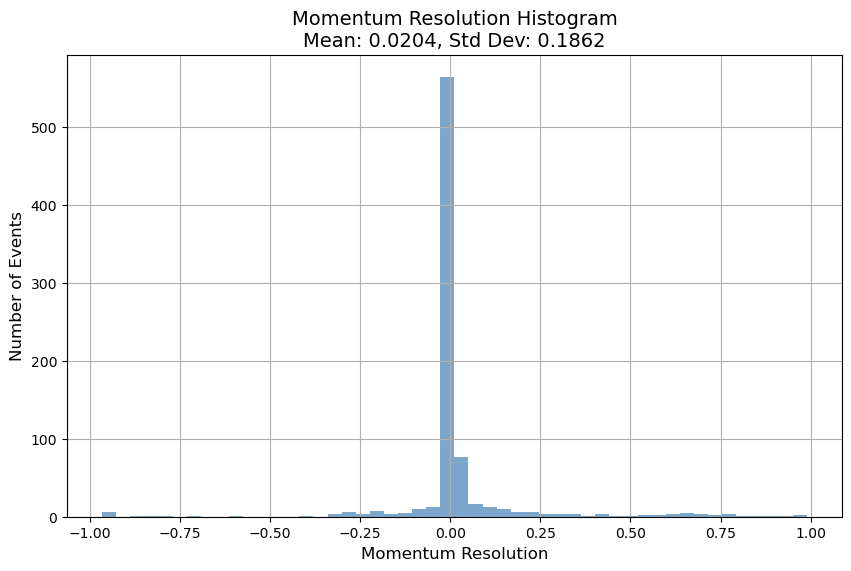

In [392]:
# Compare with true momentum and charge to fully reconstruct the momentum.

# Match truth information to the reconstructed pairs based on EventID and closest Phi value
def match_truth(row):
    event_truth = truth_pd[truth_pd['EventID'] == row['EventID']]
    charged = event_truth[event_truth['Charge'] != 0]
    candidates = charged if len(charged) > 0 else event_truth
    phi_diff = np.abs(candidates['Phi'] - row['Phi1'])
    closest = candidates.loc[phi_diff.idxmin()]
    return pd.Series({'TrueCharge': closest['Charge'], 'TrueMomentum': closest['Momentum'], 'TrueSpecies': closest['TrueSpecies']})

pairs_df = pairs_df.join(pairs_df.apply(match_truth, axis=1))

# Calculate Momentum Resolution
pairs_df['Mom. Resolution'] = (pairs_df['Mom'] - pairs_df['TrueMomentum']) / pairs_df['TrueMomentum']
reasonable_mom = (pairs_df['Mom'] > 0.5) & (pairs_df['Mom'] < 100) & (pairs_df['TrueMomentum'] > 0.5)  # Filter for reasonable momentum values
pairs_clean = pairs_df[reasonable_mom]

mean, std = pairs_clean['Mom. Resolution'].mean(), pairs_clean['Mom. Resolution'].std()
plt.figure(figsize=(10, 6)) 
plt.hist(pairs_clean['Mom. Resolution'], bins=50, color='steelblue', alpha=0.7)
plt.title(f'Momentum Resolution Histogram\nMean: {mean:.4f}, Std Dev: {std:.4f}', fontsize=14)
plt.xlabel('Momentum Resolution', fontsize=12)
plt.ylabel('Number of Events', fontsize=12)
plt.grid()
plt.show()

**Figure: Momentum Resolution.**

Used $(p_{reco} - p_{true})/p_{true}$ for all paired tracks with $p \gt 0.5$ GeV. The distribution is tightly centered around zero with two known asymmetric tails:

- **Low Momentum** (< ~1 GeV): Multiple Coulumb scattering in the tracker silicon competes with magnetic bending, degrading the sagitta measurement. 
- **High Momentum** (> ~20 GeV): The bend angle itself becomes vanishingly small (sub-degree for a 45 GeV track in this geometry), so angular measurement precision dominates the relative error. This is a known property of sagitta-based methods as $\Delta p/p$ grows with $p$.

### 2.2 Charge from Curvature

The momentum calculation above discards the direction fo the bend ('abs()' on $\Delta \Phi$). Retaining its sign gives the charge for free from the same measurement. The sign convention was calibrated against the truth charge on a muon-pair as it has no photon-conversion ambiguity.

In [393]:
# Assigns +1 for SignDPhi < 0 and -1 for SignDPhi > 0, indicating the reconstructed charge based on the sign of the phi difference
pairs_df['RecoCharge'] = np.where(pairs_df['SignedDPhi'] > 0, -1, 1)

pairs_df['ChargeCorrect'] = pairs_df['RecoCharge'] == pairs_df['TrueCharge']
print(f"Overall: {pairs_df['ChargeCorrect'].mean()*100:.2f}%")
for sp in sorted(pairs_df['TrueSpecies'].unique()):
    subset = pairs_df[pairs_df['TrueSpecies'] == sp]
    print(f"{sp}: {subset['ChargeCorrect'].mean()*100:.2f}%  (n={len(subset)})")

Overall: 98.53%
antimuon: 100.00%  (n=146)
antiproton: 98.04%  (n=51)
electron: 100.00%  (n=148)
muon: 99.33%  (n=149)
photon: 0.00%  (n=5)
pion+: 96.23%  (n=53)
pion-: 100.00%  (n=58)
positron: 99.33%  (n=150)
proton: 96.49%  (n=57)


**Note** A small number of tracks matched to a truth photon (charge 0) despite originating in the tracker as 'PositionFinder' only records hits from charged particles, this can only mean the photon pair-converted inside the tracker silicon and produced a charged secondary with no primary truth row of its own.

### 2.3 Calorimeter Energy

Total calorimeter energy is compared against the sum of the true momenta across all particles in the event, an important feature for events with hard final-state radiation as the energy splits unevenly between a radiating lepton and the photon it produces.

Teo populations are excluded from calibration and resolution:
- **Muons**, which are minimum-ionizing particles and do not deposit enough energy that would scale with momentum. Real experiments reconstruct muon momentum from tracking for the same reason.
- **Events Outside Angular Acceptance** (|0| within ~47° of the beam axis), where particles exit the world volume without crossing any active layer. Including these would contaminate the calibration constant with pure geometric loss rather than genuine shower response.

Here we apply a global calibration $($E_{calibrated} - \Sigma E_{true})/ \Sigma E_{true}$ across all particle types. This is a simplification with a real physical cost as electromagnetic and hadronic showers are not sampled with equal efficiency in the detector. So a single constant systematically miscalibrates whichever population deviates most from the average. For this reason, a per-species calibration will be done again once particle classification has been achieved and the two reconstructions will be analyzed later.


In [394]:
# Saves Total energy per event 
em_total = em_pd.groupby('EventID')['Energy'].sum()
h_total = h_pd.groupby('EventID')['Energy'].sum()

# Saves per layer shower profiles
em_layers = em_pd.pivot_table(index = 'EventID', columns = 'LayerID', values = 'Energy', fill_value = 0)
h_layers = h_pd.pivot_table(index = 'EventID', columns = 'LayerID', values = 'Energy', fill_value = 0)

# Shower-Shape Features
# Define a function to calculate shower shape features for a given DataFrame
def shower_shape_features(df, prefix, energy_threshold=1e-6):
    # Check if the DataFrame is empty and return an empty DataFrame with the appropriate columns if it is
    if len(df) == 0:
        return pd.DataFrame(columns=[f'{prefix}_Total', f'{prefix}_NLayersHit', f'{prefix}_MeanDepth', f'{prefix}_ShowerMaxLayer'])
    
    # Group by EventID and LayerID, summing the energy deposits
    g = df.groupby('EventID')
    total = g['Energy'].sum().rename(f'{prefix}_Total') # Total energy deposited in the calorimeter for each event
    hit_mask = df['Energy'] > energy_threshold # Mask for layers with energy deposits above the threshold
    n_layers_hit = df[hit_mask].groupby('EventID').size().reindex(total.index, fill_value=0).rename(f"{prefix}_NLayersHit") # Number of layers hit for each event
    weighted = df.assign(_w=df['LayerID'] * df['Energy']) # Weighted sum of layer IDs multiplied by energy deposits
    mean_depth = (weighted.groupby('EventID')['_w'].sum()/total.replace(0, np.nan)).rename(f"{prefix}_MeanDepth") # Mean depth of the shower for each event
    idx_of_max = df.loc[df.groupby('EventID')['Energy'].idxmax()] # Find the index of the maximum energy deposit for each event
    shower_max = idx_of_max.set_index('EventID')['LayerID'].rename(f"{prefix}_ShowerMaxLayer") # Layer ID of the maximum energy deposit for each event
    return pd.concat([total, n_layers_hit, mean_depth, shower_max], axis=1)

# Define a function to calculate the early/late energy ratio for a given DataFrame
def early_late_ratio(df, n_early = 25):
    g = df.groupby('EventID')
    total = g['Energy'].sum()
    early = df[df['LayerID'] < n_early].groupby('EventID')['Energy'].sum().reindex(total.index, fill_value=0)
    return (early / total.replace(0, np.nan)).rename('HC_EarlyLateRatio')

    # Shower Shape Features
em_shape = shower_shape_features(em_pd, 'EM').reset_index()
hc_shape = shower_shape_features(h_pd, 'HC').reset_index()
hc_early = early_late_ratio(h_pd, n_early = 25).reset_index() # Needs possible retuning

# Calculate the shower shape parameters for HCal
hc_shape_lookup = hc_shape.set_index('EventID')[['HC_ShowerMaxLayer', 'HC_MeanDepth']].to_dict('index')

In [395]:
# Build truth dataframe for matching with reconstructed events

def match_event_truth(event_id):
    event_truth = truth_pd[truth_pd['EventID'] == event_id]
    if len(event_truth) == 0:
        return pd.Series({'TrueSpecies': None, 'TrueType': None, 'TrueMomentum': np.nan, 'TrueTheta': np.nan})
    
    # Check if the event has tracker hits
    saw_track = event_id in events_with_tracker_hits

    # Determine the reference phi based on the presence of muon hits or tracker hits
    muon_hit = muon_pd[muon_pd['EventID'] == event_id]
    if len(muon_hit) > 0:
        ref_phi = muon_hit['Phi'].iloc[0]
    elif event_id in events_with_tracker_hits:
        tr_hits = track1_pd[track1_pd['EventID'] == event_id]
        ref_phi = tr_hits['Phi'].iloc[0] if len(tr_hits) > 0 else 0
    else:
        ref_phi = 0

    charged = event_truth[event_truth['Charge'] != 0]
    candidates = charged if (saw_track and len(charged) > 0) else event_truth 
    phi_diff = np.abs(candidates['Phi'] - ref_phi)
    closest = candidates.loc[phi_diff.idxmin()]
    return pd.Series({'TrueSpecies': closest['TrueSpecies'], 'TrueType': closest['TrueType'], 'TrueMomentum': closest['Momentum'], 'TrueTheta': closest['Theta']})

event_truth_df = pd.DataFrame({'EventID': all_event_ids})
event_truth_df = event_truth_df.join(event_truth_df['EventID'].apply(match_event_truth))
event_truth_df['Total_Energy'] = event_truth_df['EventID'].map(em_total).fillna(0) + event_truth_df['EventID'].map(h_total).fillna(0)

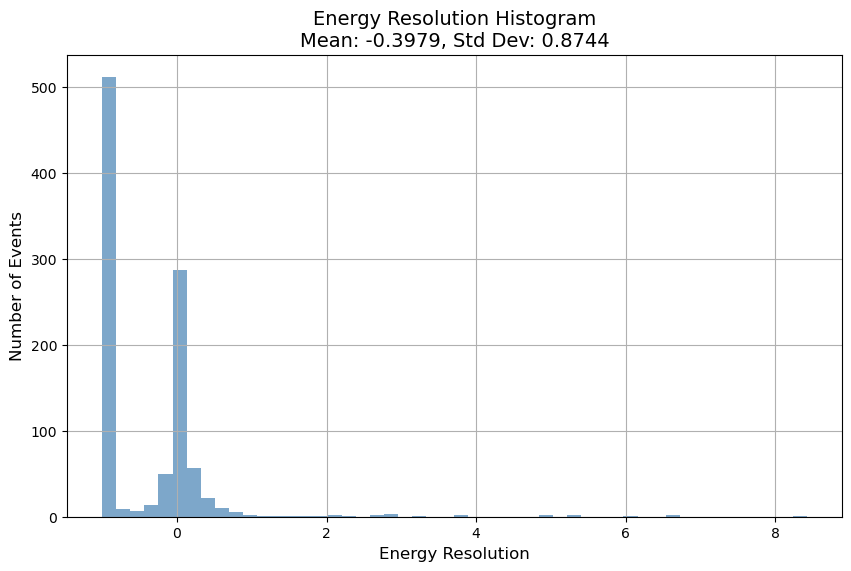

In [396]:
# Calibration: mean ratio of true momentum to detected energy for well-populated events
true_total_mom = truth_pd.groupby('EventID')['Momentum'].sum().rename('TrueTotalMomentum')
event_truth_df = event_truth_df.join(true_total_mom, on='EventID', how = 'left')

# Muon exclusion
events_with_muon = set(truth_pd.loc[truth_pd['Particle Code'] == 1, 'EventID'])
non_muon_mask = ~event_truth_df['EventID'].isin(events_with_muon)

# Exclude angular blind spot
acceptance_edge = np.arctan(860/800) # Full EM stack depth and not just inner radius
in_acceptance = (event_truth_df['TrueTheta'] > acceptance_edge) & (event_truth_df['TrueTheta'] < np.pi - acceptance_edge)

calib_mask = non_muon_mask & in_acceptance & (event_truth_df['TrueTotalMomentum'] > 1.0) & (event_truth_df['Total_Energy'] > 0)
cali_factor = event_truth_df.loc[calib_mask, 'TrueTotalMomentum'].mean() / event_truth_df.loc[calib_mask, 'Total_Energy'].mean()

event_truth_df['E_cali'] = event_truth_df['Total_Energy'] * cali_factor
e_res = event_truth_df.copy()
e_res['Energy Resolution'] = (e_res['E_cali'] - e_res['TrueTotalMomentum']) / e_res['TrueTotalMomentum']

plt.figure(figsize=(10, 6))
plt.hist(e_res['Energy Resolution'], bins=50, color='steelblue', alpha=0.7)
plt.title(f'Energy Resolution Histogram\nMean: {e_res["Energy Resolution"].mean():.4f}, Std Dev: {e_res["Energy Resolution"].std():.4f}', fontsize=14)
plt.xlabel('Energy Resolution', fontsize=12)
plt.ylabel('Number of Events', fontsize=12)
plt.grid()
plt.show()

**Figure: Energy Resolution, Global Calibration** 
Using a single calibration factor across all particle types results in a broad spread with two peaks. This is due to the miscalibration by the same constant as they pull the two calorimeter distributions in opposite directions.

## 3. Particle Type Classification

### 3.1 Event Level Classification
Each event is classified by a detector signature with no reference to truth. Classification operates at event level (one decision per event) while charge identification operates on track level. Events with two charged particles (e.g. dilepton pairs), the event-level type decision is graded against whichever truth particle the matching logic resolves to. This is discussed further in Step 4.

'ParticleCode' 3 (proton) and 4 (pion) both map to 'hadron': this detector cannot distinguish them from each other using energy fraction and tracker hits alone (both present as a tracker hit + HCal-dominant shower).

In [397]:
# Create a new DataFrame to store the results of particle classification
results = []
for event_id in all_event_ids:
    # Get the hits for the current event from each detector
    em_hits = em_pd[em_pd['EventID'] == event_id]
    h_hits = h_pd[h_pd['EventID'] == event_id]
    muon_hits = muon_pd[muon_pd['EventID'] == event_id]

    # Calculate the total energy deposited in the EM and H calorimeters
    em_energy = em_hits['Energy'].sum()
    h_energy = h_hits['Energy'].sum()
    total_energy = em_energy + h_energy
    em_frac = em_energy / total_energy if total_energy > 0 else 0

    # Determine if there are hits in the muon detector and tracker detectors
    muon_hit = len(muon_hits) > 0
    tracker_hit = event_id in events_with_tracker_hits
    tracker2_hit = event_id in events_with_tracker2_hits

    # Shape of the shower in the hadronic calorimeter
    shape = hc_shape_lookup.get(event_id, {})
    shower_max = shape.get('HC_ShowerMaxLayer', np.nan)
    mean_depth = shape.get('HC_MeanDepth', np.nan)

    # Classify the particle type based on the energy deposits and detector hits
    if muon_hit:
        particle_type = 'muon'
    elif total_energy == 0:
        particle_type = 'unclassified'
    elif not tracker2_hit and em_frac > 0.95:
        particle_type = 'photon'
    elif tracker2_hit and em_frac > 0.95:
        particle_type = 'electron'
    elif tracker_hit:
        particle_type = 'hadron'
    else:
        particle_type = 'unclassified'

    results.append({
        'EventID': event_id,
        'EM_Energy': em_energy,
        'H_Energy': h_energy,
        'Total_Energy': total_energy,
        'EM_Fraction': em_frac,
        'Muon_Hit': muon_hit,
        'Tracker_Hit': tracker_hit,
        'Tracker2_Hit': tracker2_hit,
        'Particle_Type': particle_type,
        'HC_ShowerMaxLayer': shower_max,
        'HC_MeanDepth': mean_depth,
    })

results_df = pd.DataFrame(results)
# Merge the results DataFrame with the shower shape features and early/late energy ratio
results_df = results_df.merge(em_shape, on='EventID', how='left', suffixes = ('', '_dup'))
results_df = results_df.merge(hc_shape[['EventID',  'HC_Total', 'HC_NLayersHit']], on='EventID', how='left')
results_df = results_df.merge(hc_early, on='EventID', how='left')

# Reuse Step 2's Truth Matching
results_df = results_df.merge(event_truth_df[['EventID', 'TrueSpecies', 'TrueType']], on='EventID', how='left')
results_df['Matched'] = results_df['Particle_Type'] == results_df['TrueType']


In [398]:
overall_efficiency = results_df['Matched'].sum() / len(results_df) * 100
print(f"Overall Efficiency: {overall_efficiency:.2f}%")
for particle in ['electron', 'muon', 'photon', 'hadron', 'unclassified']:
    subset = results_df[results_df['TrueType'] == particle]
    if len(subset) > 0:
        eff = subset['Matched'].sum() / len(subset) * 100
        print(f"{particle.capitalize()} Efficiency: {eff:.2f}% (n={len(subset)})")

Overall Efficiency: 64.80%
Electron Efficiency: 79.02% (n=224)
Muon Efficiency: 100.00% (n=244)
Photon Efficiency: 41.98% (n=162)
Hadron Efficiency: 42.97% (n=370)


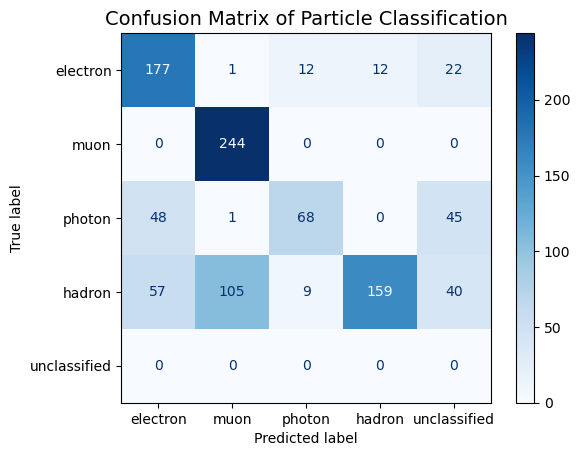

In [399]:
labels = ['electron', 'muon', 'photon', 'hadron', 'unclassified']
cm = confusion_matrix(results_df['TrueType'], results_df['Particle_Type'], labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix of Particle Classification', fontsize=14)
plt.show()

#### Results:

**Muon**: A muon hit is an unambiguous signal with no contamination in either direction.

**Photon -> Electron (48)**: Roughly half are genuine in-tracker pair conversion (a photon converting before Tracker2 is indistinguishable from an electron at that point) and a remainder trace to FSR collinearity in truth-matching for multi-particle events.

**Photon -> Unclassified (45) & Hadron -> Unclassified (40)**: Consistent with the detector's ≈47° angular acceptance edge, where particles emitted near the beam axis exit the barrel's open ends without crossing any active layer.

**Hadron -> Muon (105)**: Hadronic punch-through, where a charged hadron that does not undergo a nuclear interaction across the full HCal depth exits as a bare minimum-ionizing track, indistinguishable from a real muon by hit pattern alone. An expected limitation of finite calorimeter depth.

**Hadron -> Electron(57)**: Low momentum hadrons (gun range down to 200 MeV) with a range of only millimeters in lead stop within the EM section and deposit their energy there. This is then classified as an EM-dominated signature indistinguishable from a real electron shower without additional information (dE/dx was tested as a discriminator but failed at insufficient momenta).

### 3.2 Attaching Charge to Classified Events

Type classification above operates at event level. Charge identification (step 2.2) operates at track level. Here we broadcast each event's 'ParticleType' onto every track that event produced.

In [400]:
combined = results_df.drop(columns=['TrueSpecies']).merge(
    pairs_df[['EventID', 'TrackID', 'RecoCharge', 'TrueCharge', 'TrueSpecies']], on='EventID', how='inner')

def combine_label(row):
    if row['Particle_Type'] in ('electron', 'muon', 'hadron'):
        sign = '+' if row['RecoCharge'] > 0 else '-'
        return f"{row['Particle_Type']}_{sign}"
    return row['Particle_Type']

combined['CombinedSpecies'] = combined.apply(combine_label, axis=1)
combined['TypeCorrect'] = combined['Particle_Type'] == combined['TrueType']
combined['ChargeCorrect'] = combined['RecoCharge'] == combined['TrueCharge']

print(f"For events with Electron, Muon, or Hadron classification:")
print(f"Type Correct (Step 3): {combined['TypeCorrect'].mean()*100:.2f}%")
type_ok = combined[combined['TypeCorrect']]
print(f"Charge Correct, Given type already correct: {type_ok['ChargeCorrect'].mean()*100:.2f}%")
full_correct = combined['TypeCorrect'] & combined['ChargeCorrect']
print(f"Full Species Correct (type & charge): {full_correct.mean()*100:.2f}%")

For events with Electron, Muon, or Hadron classification:
Type Correct (Step 3): 91.19%
Charge Correct, Given type already correct: 99.46%
Full Species Correct (type & charge): 90.70%


These results are computed for events with a complete two-layer tracker pair. This result should be read as "accuracy given a clean track was formed", not a replacement for the 64.80\% efficiency across all events.

### 3.3 Particle Type Energy Calibration

Testing if calibration improves with species info, even with an imperfect classifier.

In [401]:
# Pull in the event-level true total momentum
results_df = results_df.merge(event_truth_df[['EventID', 'TrueTotalMomentum']], on='EventID', how='left')
non_muon_mask_op = results_df['Particle_Type'] != 'muon'

min_energy_floor = 1e-6 # Excludes true non-detections only
calib_mask_op = non_muon_mask_op & (results_df['TrueTotalMomentum'] > 1.0) & (results_df['Total_Energy'] > min_energy_floor)

calib_factors_op = {}
for t in ['electron', 'photon', 'hadron']:
    subset = results_df[calib_mask_op & (results_df['Particle_Type'] == t)]
    factor = subset['TrueTotalMomentum'].mean() / subset['Total_Energy'].mean()
    calib_factors_op[t] = factor
    print(f"{t}: Operational Calibration Factor: {factor:.4f} (n={len(subset)})")

results_df['E_cali_op'] = results_df.apply(
    lambda row: row['Total_Energy'] * calib_factors_op.get(row['Particle_Type'], np.nan), axis=1
)

e_res_op = results_df[calib_mask_op].copy()
e_res_op['Energy Resolution'] = (e_res_op['E_cali_op'] - e_res_op['TrueTotalMomentum']) / e_res_op['TrueTotalMomentum']

print(f"Mean: {e_res_op['Energy Resolution'].mean():.4f}, Std Dev: {e_res_op['Energy Resolution'].std():.4f}")


electron: Operational Calibration Factor: 4.9796 (n=237)
photon: Operational Calibration Factor: 35.7837 (n=39)
hadron: Operational Calibration Factor: 8.2299 (n=148)
Mean: 0.8139, Std Dev: 1.9149


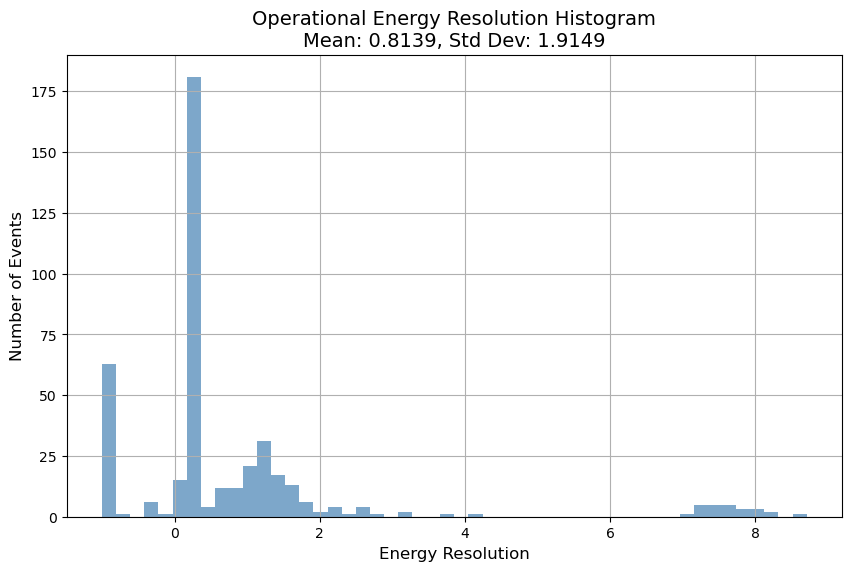

In [402]:
plt.figure(figsize=(10, 6))
plt.hist(e_res_op['Energy Resolution'], bins=50, color='steelblue', alpha=0.7)
plt.title(f'Operational Energy Resolution Histogram\nMean: {e_res_op["Energy Resolution"].mean():.4f}, Std Dev: {e_res_op["Energy Resolution"].std():.4f}', fontsize=14)
plt.xlabel('Energy Resolution', fontsize=12)
plt.ylabel('Number of Events', fontsize=12)
plt.grid()
plt.show()

Calibrating per 'Particle_Type' was tested as the realistic, deployable version of an idealized case. It performed worse than even the naive global calibration as the 'Particle_Type' bucket's calibration factor is itself computed from a population containing the same misclassifications already catalogued. A calibration factor derived from a contaminated population does not transfer well to the population it was meant to correct. Further comparisons will be made with the classification and reconstruction with the ML model.

### 3.4 Energy Deposition

Observing the distribution of energy in the detector and across all calorimeter layers.

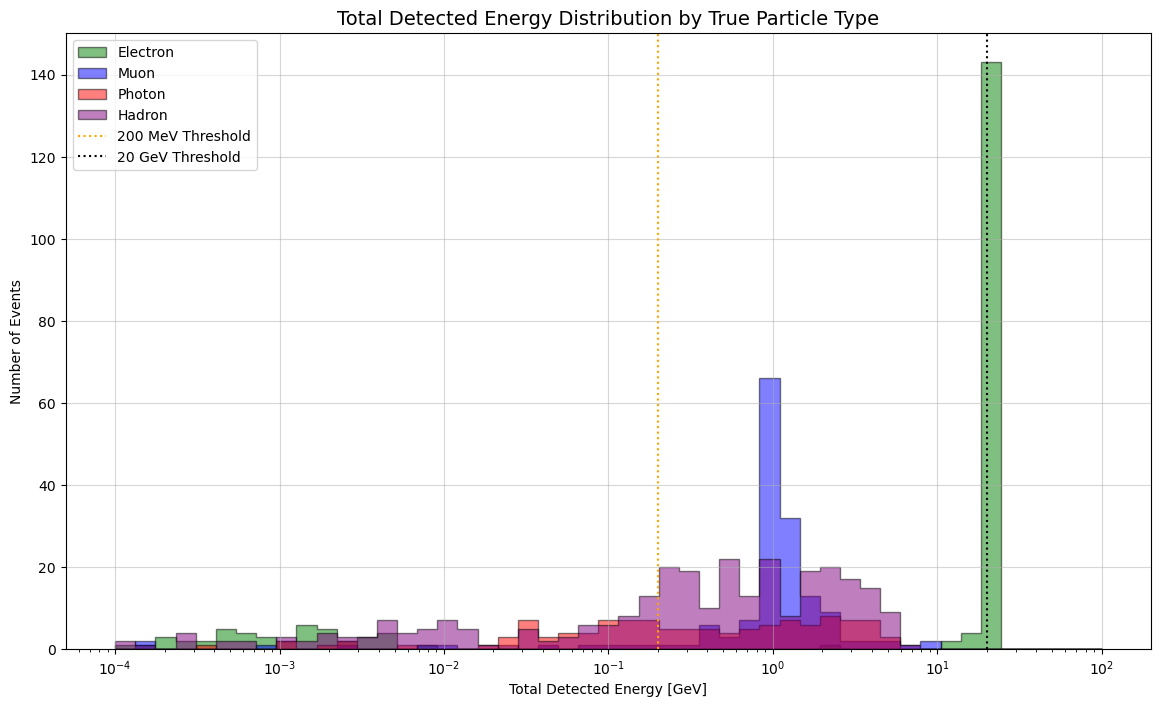

In [403]:
colors = {'electron': 'green', 'muon': 'blue', 'photon': 'red', 'hadron': 'purple'}
bins = np.logspace(-4, 2, 50)

plt.figure(figsize=(14,8))
for ptype, color in colors.items():
    # Using TrueType here to characterize detector response itself, independent of classification accuracy
    subset = results_df[(results_df['TrueType'] == ptype) & (results_df['Total_Energy'] > 0)]
    plt.hist(subset['Total_Energy'], bins=bins, color=color, alpha=0.5, label=ptype.capitalize(), histtype='stepfilled', edgecolor='black')

plt.axvline( x=0.2, color = 'Orange', linestyle = ':', linewidth = 1.5, label = '200 MeV Threshold')
plt.axvline(x = 20, color = 'Black', linestyle = ':', linewidth = 1.5, label = '20 GeV Threshold')
plt.xscale('log')
plt.xlabel('Total Detected Energy [GeV]')
plt.ylabel('Number of Events')
plt.title('Total Detected Energy Distribution by True Particle Type', fontsize=14)
plt.legend()
plt.grid(alpha = 0.5)
plt.show()

This plot shows the raw, uncalibrated detector energy. Here we see detected energy across the requested two magnitude range (200 MeV - 20 GeV) with features that follow the physics inside the detector. 

A tall green spike (~20-25 GeV) from electrons exhibit the dilepton pair-production population. The true momentum is around ~45.5 GeV per lepton (summing to the decayed Z-boson that produces the event), but the raw detected energy is suppressed by the sampling fraction that the calibration factor adjusts. 

Muons show no equivalent spike despite also exhibiting ~45.5 GeV true momentum due to their status of minimum-ionizing, explaining why they cluster at low detected energy regardless of how energetic they are.

The hadron/photon spread is more smooth as they are produced from particle gun that samples energy log-uniformly across 0.1 - 20GeV. Therefore, there is no single energy value pileup.

The populated tail below the 200 MeV line comes from: sub-threshold FSR photons with true momentum near zero, punch-through/angular-acceptance hadrons (real momentum near-zero), and minimum-ionizing muons (near-zero energy detected, with larger true momentum).

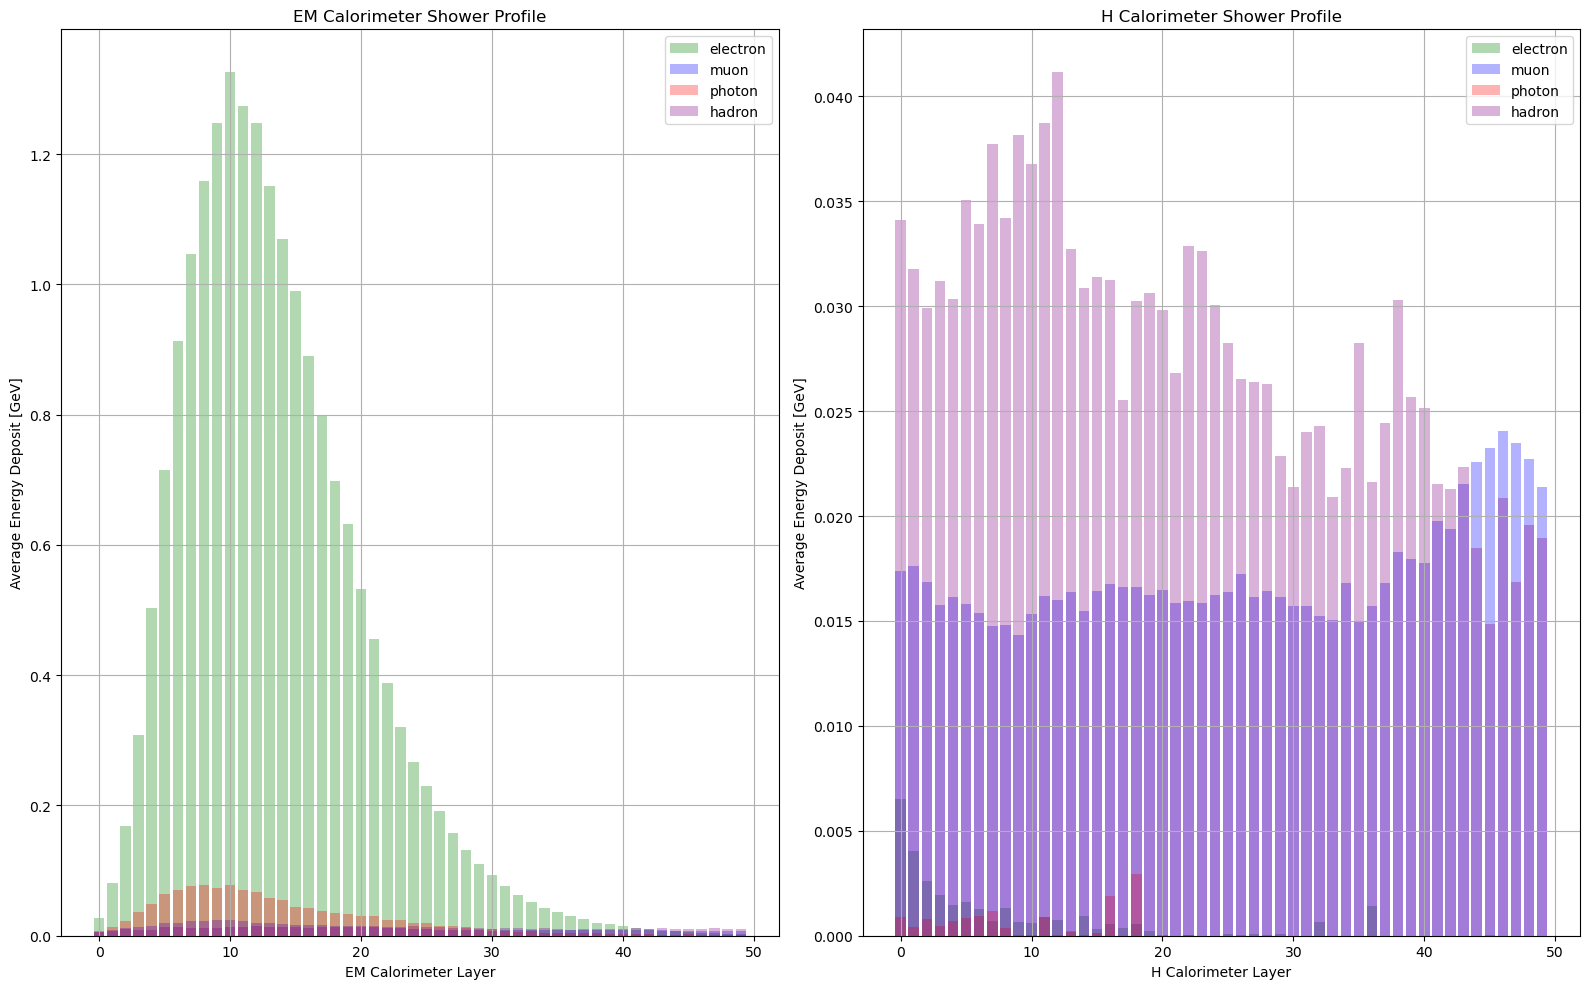

In [404]:
# Shower Profiles for each particle type in both calorimeters.

event_to_type = results_df.set_index('EventID')['TrueType'].to_dict()
em_pd['TrueType'] = em_pd['EventID'].map(event_to_type)
h_pd['TrueType'] = h_pd['EventID'].map(event_to_type)

colors = {'electron': 'green', 'muon': 'blue', 'photon': 'red', 'hadron': 'purple'}

plt.figure(figsize=(16, 10))
plt.subplot(1, 2, 1)
for ptype, color in colors.items():
    subset = em_pd[em_pd['TrueType'] == ptype]
    profile = subset.groupby('LayerID')['Energy'].mean()
    plt.bar(profile.index, profile.values, color=color, label=ptype, alpha=0.3)
plt.xlabel('EM Calorimeter Layer'); plt.ylabel('Average Energy Deposit [GeV]')
plt.title('EM Calorimeter Shower Profile'); plt.legend(); plt.grid()

plt.subplot(1, 2, 2)
for ptype, color in colors.items():
    subset = h_pd[h_pd['TrueType'] == ptype]
    profile = subset.groupby('LayerID')['Energy'].mean()
    plt.bar(profile.index, profile.values, color=color, label=ptype, alpha=0.3)
plt.xlabel('H Calorimeter Layer'); plt.ylabel('Average Energy Deposit [GeV]')
plt.title('H Calorimeter Shower Profile'); plt.legend(); plt.grid()

plt.tight_layout()
plt.show()

The Electromagnetic Calorimeter shows clean rise to peak around layers 8-16, with smooth exponential decay afterward. The most prominent result is the electron and the second (although much lower) is the photon, results that follow real physics across EM calorimeters.

In the Hadronic panel, we see results that align more with hadronic showers, with the pions and protons depositing most of their energy across the full layer spectrum. The shape of the showers don't follow as smoothly as the EM calorimeter as each individual hadron interacts at a randomly varying depth through nuclear-interactions that are exponentially distributed and not fixed (no Bragg Peak like electrons).

Across both calorimeters, the muon deposited little energy, with interactions depending on ionization (through Bethe-Bloch) unlike the electrons pair-production and bremmsstrahlung (which scales with Z in the absorber material). Muon bremsstrahlung is suppressed by $(m_e/m_\mu)^2$ relative to an electron, so muons largely cannot shower in either absorber regardless of material. This results in the structureless muon profile in the HCal, showcasing the minimum-ionizing energy loss.

The hadron profile also helps explain the results in the confusion matrix, as the hadron average sitting only modestly above the muon baseline, as a population of true hadrons deposit minimum-ionizing particle-like energy that is indistinguishable from a muon. 

## 4. Gradient Boosting Classifier - Machine Learning Model

### 4.1 Model Architecture

Using a single decision tree is very similar to the rule-based classifier that was already developed. It asks a sequence of yes/no questions about feature values and arrives at a prediction by following answers along the branching path. Here, the questions and thresholds are learned from the data to optimally split the classes at each step. Limitations come from using one fixed sequence of splits (like 'em_frac < 0.5').

The Gradient Boosting builds many small trees that are not independent of each other, but trains on fixing mistakes from previous trees. This is important as we have missing values in a lot of our features (like photon tracker hits and muon shower-shape features). The 'HistGradientBoostingClassifier' handles the missing values by treating it as a learnable signal. In addition, it doesn't utilize feature scaling, meaning there is no need to normalize across steps for values that vary significantly in magnitude (like the deposited energies across the detector that could be seen above). Along with that, the amount of data with few features is a suitable structure for a gradient-boosted tree without requiring extensive hyperparameter tuning.

In [405]:
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.inspection import permutation_importance
from scipy import stats

SEED = 64

In [406]:
# Feature Table

# Track-Level Features aggregated to Event Level
track_features = pairs_df.groupby('EventID').agg(
    NumTracks=('TrackID', 'count'),
    MeanMom=('Mom', 'mean'),
    MaxMom=('Mom', 'max'),
).reset_index()

# Average dE/dx for each event, combining both tracker hits
tracker_hits = pd.concat([track1_pd, track2_pd])
g = tracker_hits.groupby('EventID')
dedx_features = (g['EnergyDeposit'].sum() / g['PathLength'].sum()).rename('AvgDEdx').reset_index()

# Combine all features into a single DataFrame
feature_df = results_df[['EventID', 'EM_Energy', 'H_Energy', 'Total_Energy', 'EM_Fraction', 'Muon_Hit', 'Tracker_Hit', 'Tracker2_Hit',
                         'EM_Total', 'EM_NLayersHit', 'EM_MeanDepth', 'EM_ShowerMaxLayer', 'HC_Total', 'HC_NLayersHit', 'HC_ShowerMaxLayer',
                         'HC_MeanDepth', 'HC_EarlyLateRatio', 'TrueType']].copy()

features_df = feature_df.merge(track_features, on='EventID', how='left')
features_df = features_df.merge(dedx_features, on='EventID', how='left')

for col in ['Muon_Hit', 'Tracker_Hit', 'Tracker2_Hit']:
    features_df[col] = features_df[col].astype(int)
features_df = features_df.dropna(subset=['TrueType']) # Drop rows where TrueType is NaN

ML Classifier (Test Set):
              precision    recall  f1-score   support

    electron       0.89      0.84      0.86        67
      hadron       0.90      0.85      0.87       111
        muon       0.89      0.96      0.92        73
      photon       0.75      0.82      0.78        49

    accuracy                           0.87       300
   macro avg       0.86      0.86      0.86       300
weighted avg       0.87      0.87      0.87       300


    Training Accuracy: 96.29%, Test Accuracy: 86.67%

    Cross-Validation Score: 88.60%, +/- 0.00%


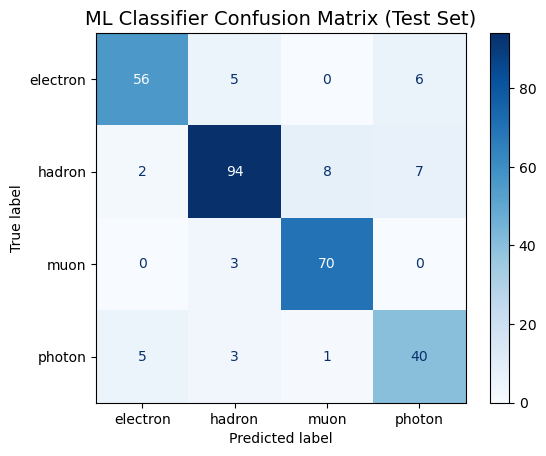


Rule-based Classifier Accuracy on ML Test Set: 64.33%
ML Classifier Accuracy on Same Test Set: 86.67%


In [407]:
# Define the feature columns and target variable for the machine learning model
feature_cols = ['EM_Energy', 'H_Energy', 'Total_Energy', 'EM_Fraction', 'Muon_Hit', 'Tracker_Hit', 'Tracker2_Hit',
                'EM_Total', 'EM_NLayersHit', 'EM_MeanDepth', 'EM_ShowerMaxLayer', 'HC_Total', 'HC_NLayersHit', 'HC_ShowerMaxLayer',
                 'HC_MeanDepth', 'HC_EarlyLateRatio', 'NumTracks', 'MeanMom', 'MaxMom', 'AvgDEdx']

X = features_df[feature_cols]
Y = features_df['TrueType']

X_train, X_test, Y_train, Y_test, eventid_train, eventid_test = train_test_split(X, Y, feature_df['EventID'], test_size = 0.3, random_state = SEED, stratify = Y)

clf = HistGradientBoostingClassifier(random_state=SEED)
clf.fit(X_train, Y_train)
Y_pred = clf.predict(X_test)
train_acc = accuracy_score(Y_train, clf.predict(X_train))
test_acc = accuracy_score(Y_test, clf.predict(X_test))
cv_scores = cross_val_score(clf, X, Y, cv=5).mean()

print("ML Classifier (Test Set):")
print(classification_report(Y_test, Y_pred))
print(f"\n    Training Accuracy: {train_acc*100:.2f}%, Test Accuracy: {test_acc*100:.2f}%")
print(f"\n    Cross-Validation Score: {cv_scores*100:.2f}%, +/- {cv_scores.std()*100:.2f}%" )

# Confusion Matrix for the ML Classifier
labels = sorted(Y.unique())
cm = confusion_matrix(Y_test, Y_pred, labels=labels)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels).plot(cmap=plt.cm.Blues)
plt.title('ML Classifier Confusion Matrix (Test Set)', fontsize=14)
plt.show()

# Fair Comparison: Rule-based accuracy on this exact same held-out subset
rule_based_test = results_df[results_df['EventID'].isin(eventid_test)]
rule_based_test_acc = (rule_based_test['Particle_Type'] == rule_based_test['TrueType']).mean() * 100
print(f'\nRule-based Classifier Accuracy on ML Test Set: {rule_based_test_acc:.2f}%')
print(f'ML Classifier Accuracy on Same Test Set: {(Y_pred == Y_test).mean() * 100:.2f}%')

Comparing the rule-based classifier and ML model's classifier across teh same dataset isolates the comparison on which approach extracts more correct identification.The 22\% difference is substantial and can be explained with how the model dissects the different features through permutation importance. The rule-based classifier isn't 'worse', it is just limited to the decision boundaries a human can reason, while the ML model can learn boundaries in higher-dimensional combinations.

One caveat is that the ML classifier cannot output 'unclassified', as it must commit to one of the four trained classes every time. This makes the comparison meaningfully different as the ML cannot decline to guess.

In [408]:
# Check for misclassified muons as hadrons in the ML classifier
test_results = X_test.copy()
test_results['TrueType'] = Y_test.values
test_results['Predicted'] = Y_pred
muon_to_hadron = test_results[(test_results['TrueType'] == 'muon') & (test_results['Predicted'] == 'hadron')]
print(muon_to_hadron[['Muon_Hit', 'H_Energy', 'EM_Energy', 'HC_NLayersHit', 'AvgDEdx']])

     Muon_Hit  H_Energy  EM_Energy  HC_NLayersHit   AvgDEdx
842         1  0.002375   0.005814            5.0       NaN
467         1  0.000000   0.000000            NaN  5.403226
756         1  0.000023   0.000841            1.0  0.363351


Taking a look at how the ML model handled true muon misclassifications is interesting. Despite all three events containing a muon hit, the exact feature that the rule-based classifier treats as unconditional, the ML model overrode the features in favor of other input features. This is an important trade-off, as rule-based classifiers can be built on known physics to define absolute constraints ('muon-detector hit = muon' everytime). Whereas, a learned model weighs every input feature statistically, and this may result in cases where events may be outvoted by noise from unrelated features. In this case, the overall accuracy dominates with a substantial jump compared to that of the rule-based classifier, but it is something to consider.

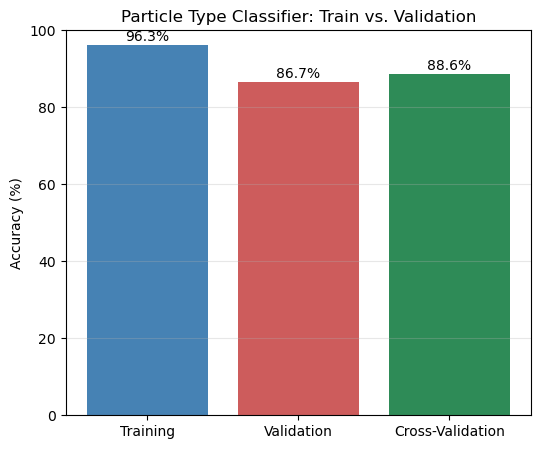

In [409]:
# Compare the training and validation accuracy of the ML classifier

plt.figure(figsize=(6, 5))
plt.bar(['Training', 'Validation'], [train_acc*100, test_acc*100], color=['steelblue', 'indianred'])
# Cross-Val score
plt.bar(['Cross-Validation'], [cv_scores*100], color='seagreen',  label='Cross-Validation Score') 
plt.ylabel('Accuracy (%)')
plt.title('Particle Type Classifier: Train vs. Validation')
plt.ylim(0, 100)
for i, v in enumerate([train_acc*100, test_acc*100, cv_scores*100]):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center')
plt.grid(alpha=0.3, axis='y')
plt.show()

Training accuracy exceeds validation accuracy, indicating there may be some overfitting (which is to be expected for a flexible ensemble model). However, the 5-fold cross-validation closely matches the single-split validation result, confirming that validation score is not an artifact of any train/test split, but just the model's true generalization performance.

### 4.2 Feature Importance

Ranking the permutation importance provides a way to understand the impact of each feature on the model's predictions by measuring the decrease in model performance when the feature's values are randomly shuffled.


In [410]:
# Feature Importance Analysis using Permutation Importance
result = permutation_importance(clf, X_test, Y_test, n_repeats=10, random_state=SEED)
importances = pd.Series(result.importances_mean, index=feature_cols).sort_values(ascending=False)
importances

Muon_Hit             0.254667
AvgDEdx              0.065000
Tracker_Hit          0.049667
H_Energy             0.047667
EM_Energy            0.043667
EM_NLayersHit        0.042000
EM_MeanDepth         0.026667
MeanMom              0.025000
NumTracks            0.022000
HC_ShowerMaxLayer    0.014000
EM_Total             0.011333
Tracker2_Hit         0.010333
HC_NLayersHit        0.006000
HC_Total             0.005333
EM_Fraction          0.002333
EM_ShowerMaxLayer    0.000667
HC_EarlyLateRatio    0.000000
MaxMom               0.000000
Total_Energy        -0.002667
HC_MeanDepth        -0.002667
dtype: float64

An important feature to measure here is the importance scale of 'AvgDEdx', as when tested as a standalone discriminator, it showed no clean separating threshold between true electrons and true hadrons. However, the same feature ranks second in permutation importance, behind only 'Muon_Hit'.

On the other note, 'HC_EarlyLateRatio' and 'MaxMom' contribute nothing and 'HC_MeanDepth' and 'Total_Energy' are listed as negative (occurs when shufflying a useless feature).

### 4.3 Energy Reconstruction Comparison

Conducting a 4-Way comparison of the global calibration, previous per-species calibration, ML classifed per-species calibration, and the idealized per-species calibration using the TrueType.

In [411]:
# Setup the feature table for the ML classifier, including track-level features and average dE/dx
track_features = pairs_df.groupby('EventID').agg(
    NumTracks=('TrackID', 'count'),
    MeanMom=('Mom', 'mean'),
    MaxMom=('Mom', 'max'),
).reset_index()

tracker_hits = pd.concat([track1_pd, track2_pd])
g = tracker_hits.groupby('EventID')
dedx_features = (g['EnergyDeposit'].sum() / g['PathLength'].sum()).rename('AvgDEdx').reset_index()

features_df = results_df[['EventID', 'EM_Energy', 'H_Energy', 'Total_Energy', 'EM_Fraction', 'Muon_Hit', 'Tracker_Hit', 'Tracker2_Hit',
                            'EM_Total', 'EM_NLayersHit', 'EM_MeanDepth', 'EM_ShowerMaxLayer', 'HC_Total', 'HC_NLayersHit', 'HC_ShowerMaxLayer',
                            'HC_MeanDepth', 'HC_EarlyLateRatio', 'TrueType']].copy()

feature_df = feature_df.merge(track_features, on='EventID', how='left')
feature_df = feature_df.merge(dedx_features, on='EventID', how='left')

for col in ['Muon_Hit', 'Tracker_Hit', 'Tracker2_Hit']:
    feature_df[col] = feature_df[col].astype(int)
feature_df = feature_df.dropna(subset=['TrueType'])

# Step: 0 Setup ML predictions via cross_val_predict (out-of-fold, no leakage)
X_full = feature_df[feature_cols]
y_full = feature_df['TrueType']
feature_df['ML_Predicted_Type'] = cross_val_predict(
    HistGradientBoostingClassifier(random_state=42), X_full, y_full, cv=5
)

# Attach ML predictions and Particle_Type onto event_truth_df so all four
# versions can be built from one consistent source table.
calib_base = event_truth_df.merge(feature_df[['EventID', 'ML_Predicted_Type']], on='EventID', how='left')
calib_base = calib_base.merge(results_df[['EventID', 'Particle_Type']], on='EventID', how='left')

acceptance_edge = np.arctan(860/800) # Reuse the acceptance edge for the angular blind spot
in_acceptance = (calib_base['TrueTheta'] > acceptance_edge) & (calib_base['TrueTheta'] < np.pi - acceptance_edge)

# Define a function to build the energy resolution for different calibration strategies
def build_resolution(df, group_col, group_values, use_acceptance_cut, label):
    non_muon = df[group_col] != 'muon'
    base_mask = non_muon & (df['Total_Energy'] > 1e-6) & (df['TrueTotalMomentum'] > 1.0)
    mask = base_mask & in_acceptance if use_acceptance_cut else base_mask

    factors = {}
    for t in group_values:
        subset = df[mask & (df[group_col] == t)]
        if len(subset) > 5:
            factors[t] = subset['TrueTotalMomentum'].mean() / subset['Total_Energy'].mean()

    calibrated = df[group_col].map(factors) * df['Total_Energy']
    result = df[mask].copy()
    result['E_calibrated'] = calibrated[mask]
    result['Energy Resolution'] = (result['E_calibrated'] - result['TrueTotalMomentum']) / result['TrueTotalMomentum']
    print(f"{label}: mean={result['Energy Resolution'].mean():.4f}, std={result['Energy Resolution'].std():.4f}, n={len(result)}")
    return result

# 1. Global: single factor, no species grouping, no acceptance cut
global_mask = (calib_base['TrueType'] != 'muon') & (calib_base['Total_Energy'] > 0) & (calib_base['TrueTotalMomentum'] > 1.0)
global_factor = calib_base.loc[global_mask, 'TrueTotalMomentum'].mean() / calib_base.loc[global_mask, 'Total_Energy'].mean()
e_res_global = calib_base[global_mask].copy()
e_res_global['Energy Resolution'] = ((e_res_global['Total_Energy'] * global_factor - e_res_global['TrueTotalMomentum'])
                                       / e_res_global['TrueTotalMomentum'])
print(f"Global: mean={e_res_global['Energy Resolution'].mean():.4f}, std={e_res_global['Energy Resolution'].std():.4f}, n={len(e_res_global)}")

# 2. Operational: per rule-based Particle_Type
e_res_operational = build_resolution(calib_base, 'Particle_Type', ['electron','photon','hadron'], False, "Operational (rule-based)")

# 3. ML: per ML-predicted type (out-of-fold, fair)
e_res_ml = build_resolution(calib_base, 'ML_Predicted_Type', ['electron','photon','hadron'], False, "ML-based")

# 4. Idealized: per TrueType, with acceptance exclusion
e_res_idealized = build_resolution(calib_base, 'TrueType', ['electron','photon','hadron'], True, "Idealized (TrueType)")

Global: mean=0.1539, std=0.7555, n=513
Operational (rule-based): mean=0.8139, std=1.9149, n=452
ML-based: mean=0.6325, std=1.2551, n=515
Idealized (TrueType): mean=0.0186, std=0.2288, n=369


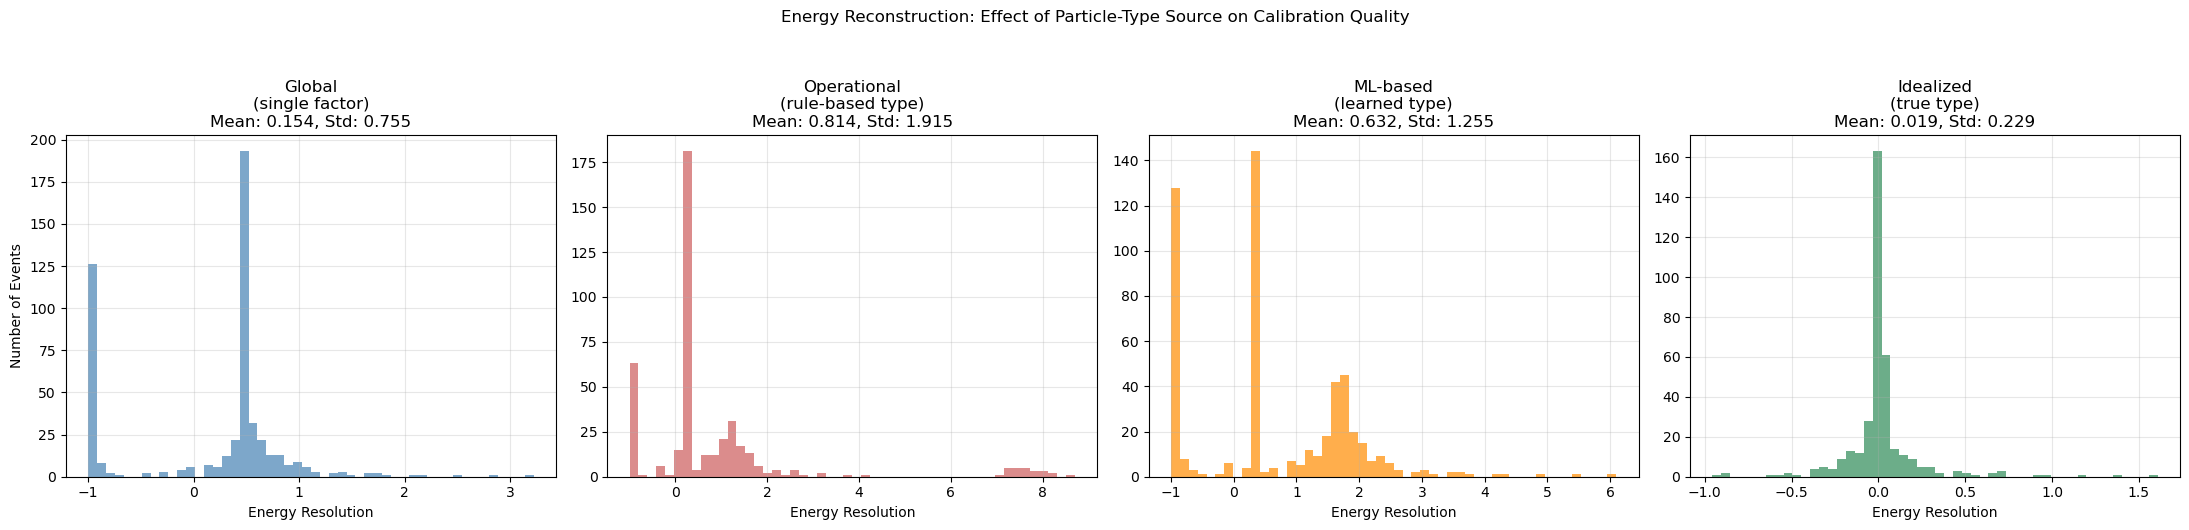

In [412]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
panels = [
    ('Global\n(single factor)', e_res_global, 'steelblue'),
    ('Operational\n(rule-based type)', e_res_operational, 'indianred'),
    ('ML-based\n(learned type)', e_res_ml, 'darkorange'),
    ('Idealized\n(true type)', e_res_idealized, 'seagreen'),
]
for ax, (title, data, color) in zip(axes, panels):
    res = data['Energy Resolution']
    ax.hist(res, bins=50, color=color, alpha=0.7)
    ax.set_title(f"{title}\nMean: {res.mean():.3f}, Std: {res.std():.3f}")
    ax.set_xlabel('Energy Resolution')
    ax.grid(alpha=0.3)
axes[0].set_ylabel('Number of Events')
plt.suptitle('Energy Reconstruction: Effect of Particle-Type Source on Calibration Quality', y=1.05)
plt.tight_layout()
plt.show()

Per-species calibration only pays off when the species labels are trustworthy: misclassification doesn't just hurt the misclassified event, it also contaminates the calibration factor for every other even sharing that bucket. With both classification methods performing worse than a single global factor, despite the ML achieving substantially higher type-classification accuracy. The idealized case shows the technique's ceiling with perfect labels, per-species calibration substantially outperforms the global approach.

The ML model's intermediate result demonstrates the relationship directly: calibration quality tracks classification quality in a measurable, monoatomic way.The practical implication is that per-species calibration is a technique worth pursuing, but only deploying once classification accuracy improves substantially beyond what either method can currently achieve.

### 4.4 Charge Comparison

Now we'll conduct a charge classification analysis using the reconstructed track pairs to compare with the track-level charge reconstruction done in step 2.2.


In [413]:
# Charge ML comparison: Is charge sign encoded anywhere besides curvature direction?

# Sagitta/R/Pt/Mom are all derived from abs(SignedDPhi) and therefore are blind to the sign of the charge. 
# AvgDEdx follows the Bethe-Block (~ charge^2), therefore is identical for both particles and antiparticles.
# Theta/Phi have no physical relationship to the charge sign as B is along the z-axis, so the charge sign only affects bending in the transverse plane.


chargeable = pairs_df[pairs_df['TrueCharge'] != 0].copy() # Excludes the 5 tracker-conversion artifacts
chargeable['AvgDEdx'] = (chargeable['EnergyDeposit1'] + chargeable['EnergyDeposit2']) / (chargeable['PathLength1'] + chargeable['PathLength2'])

# Two sets of features for charge classification: one with curvature information and one without
# This is done to evaluate the impact of curvature on charge classification performance
features_with_curvature = ['SignedDPhi', 'DPhi', 'Mom', 'AvgDEdx', 'Theta1', 'ThetaDiff']
features_without_curvature = ['DPhi', 'Mom', 'AvgDEdx', 'Theta1', 'ThetaDiff', 'Phi1', 'Phi2']

results_charge_ml = {}
for name, feats in [('With Curvature', features_with_curvature), ('Without Curvature', features_without_curvature)]:
    X_charge = chargeable[feats]
    Y_charge = chargeable['TrueCharge']
    X_train_c, X_test_c, Y_train_c, Y_test_c = train_test_split(X_charge, Y_charge, test_size=0.3, random_state=SEED, stratify=Y_charge)
    
    clf_charge = HistGradientBoostingClassifier(random_state=SEED)
    clf_charge.fit(X_train_c, Y_train_c)
    acc = accuracy_score(Y_test_c, clf_charge.predict(X_test_c))
    
    results_charge_ml[name] = acc 
    print(f"ML Charge Classifier ({name}) Accuracy: {acc * 100:.2f}%")
    print(classification_report(Y_test_c, clf_charge.predict(X_test_c)))

ML Charge Classifier (With Curvature) Accuracy: 99.18%
              precision    recall  f1-score   support

          -1       0.99      0.99      0.99       122
           1       0.99      0.99      0.99       122

    accuracy                           0.99       244
   macro avg       0.99      0.99      0.99       244
weighted avg       0.99      0.99      0.99       244

ML Charge Classifier (Without Curvature) Accuracy: 54.92%
              precision    recall  f1-score   support

          -1       0.54      0.61      0.57       122
           1       0.56      0.49      0.52       122

    accuracy                           0.55       244
   macro avg       0.55      0.55      0.55       244
weighted avg       0.55      0.55      0.55       244



With the machine learning model combining multiple individually weak signals into a stronger joint classifier, charge identification remains comparable to the previous recordings (~98\%), while the model that has the 'SignedDPhi' withheld collapses to chance (~50\%). This is consistent with the underlying physics rather than a limitation of the model. Charge sign exists in exactly one place in this detector's measurements: the direction of the magnetic bending. 

In [414]:
# Perform a binomial test to assess the statistical significance of the accuracy achieved by the "Without Curvature" model
n_correct = int(results_charge_ml['Without Curvature'] * len(Y_test_c))
binom_test = stats.binomtest(n_correct, len(Y_test_c), results_charge_ml['Without Curvature'], alternative='greater')
print(f"Binomial test p-value for 'Without Curvature' accuracy: {binom_test.pvalue:.4f}")

Binomial test p-value for 'Without Curvature' accuracy: 0.5265


The binomial test against the null hypothesis of pure chance (p=0.5) gave p = 0.5265, no statistical evidence that performance differs from random guessing. This is consistent with the physical argument that charge sign carries no information across the available features.

### 4.5 Machine Learning Analysis

Particle-type classification improved substantially under ML (~86\% vs ~64\% on the same held-out subset) because the relevant information was spread weakly across multiple features. For example, 'AvgDEdx', which alone showed no clean separating threshold, was ranked second in importance once combined with other features.

For charge identification, we saw great performance that was similar to the existing rule (99.18\% vs. ~98.5\%); whereas a model that was deliberately denied that one feature collapsed to chance (~55\%), statistically indistinguishable from random guessing despite having momentum, dE/dx, and angular information available.

All together, these results characterize when a learned model offers a real advantage over hand-written rules, when discriminating information is real but distributed amongst several individually weak features.